# Creating synthetic-wave imagery data like our GOES16

#### 0. Grab an image: closed or open cells, or complex scene. 
#### 1. Interpolate image into a netCDF file from GOES16
#### 2. advect by constant or broadly divergent wind
#### 3a. put in wave brightness B modulation by wave z', dB_dlogz
#### 3b. put in warping (pixels remapped) by wave velocity

filename: scene_IR_128km_45deg_amp3_envcenter_realistic 

`(image scene, IR/VIS, lambda, to_dir, amp, where, effects (realistic, nowarp, nomod, windexps, etc. )`

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import xarray as xr 

import scipy 
from scipy import ndimage
# Warping: https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.map_coordinates.html

In [6]:
# Image data for backdrop of synthetic dataset
!ls -1 ~/Documents/GitHub/stratocu_waves/DATA/*png

/Users/hannachaja/Documents/GitHub/stratocu_waves/DATA/image_0_2022_09_06_15_15_00Z.png
/Users/hannachaja/Documents/GitHub/stratocu_waves/DATA/image_0_2022_09_08_14_54_00Z.png
/Users/hannachaja/Documents/GitHub/stratocu_waves/DATA/image_1_2022_09_06_15_45_00Z.png
/Users/hannachaja/Documents/GitHub/stratocu_waves/DATA/image_1_2022_09_08_15_24_00Z.png
/Users/hannachaja/Documents/GitHub/stratocu_waves/DATA/image_2_2022_09_06_16_15_00Z.png
/Users/hannachaja/Documents/GitHub/stratocu_waves/DATA/image_2_2022_09_08_15_54_00Z.png
/Users/hannachaja/Documents/GitHub/stratocu_waves/DATA/image_3_2022_09_06_16_45_00Z.png
/Users/hannachaja/Documents/GitHub/stratocu_waves/DATA/image_3_2022_09_08_16_24_00Z.png
/Users/hannachaja/Documents/GitHub/stratocu_waves/DATA/image_4_2022_09_06_17_15_00Z.png
/Users/hannachaja/Documents/GitHub/stratocu_waves/DATA/image_4_2022_09_08_16_54_00Z.png
/Users/hannachaja/Documents/GitHub/stratocu_waves/DATA/image_5_2022_09_06_17_45_00Z.png
/Users/hannachaja/Documents/GitH

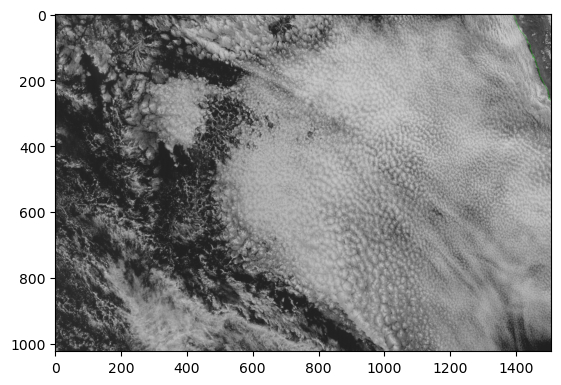

In [8]:
img = imageio.v2.imread('~/Documents/GitHub/stratocu_waves/DATA/image_2_2022_09_06_16_15_00Z.png')
#img = imageio.v2.imread('DATA/image_2_2022_09_08_15_54_00Z.png')
red = img[0:,450:,0] # just the red channel and just 400:end in the x dir
red = np.flipud(red)  # for pcolormesh, rather than imshow which has y increase downward on page 
plt.imshow(img)

# red.shape[0], red.shape[1]  # y, x on page

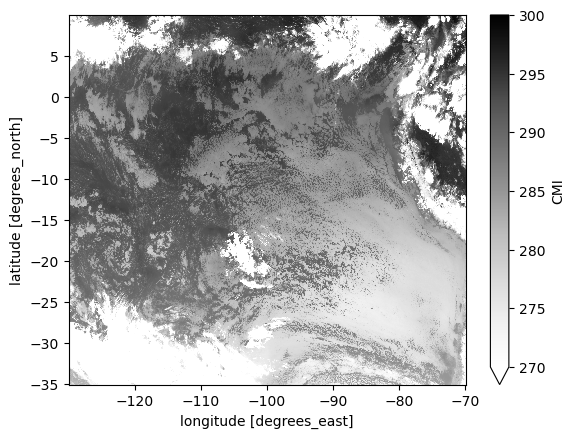

In [11]:
# Read our satellite data (.nc file), and match its 2D size with the image data 

#!ls /Users/bmapes/Box/GWaves_2023_10_11-14_SEPAC/IR/Data/IR_2023_09_28_01_15.nc
ds = xr.open_dataset('~/Box/GWaves_2023_10_11-14_SEPAC/IR/Data/IR_2023_09_28_01_15.nc')
ds.CMI.plot(cmap='Greys', vmin=270, vmax=300);

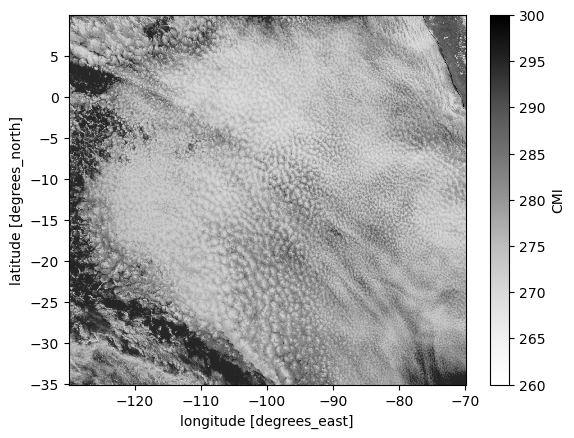

In [12]:
# Replace values and rescale to be in [270,300] K

# 1. Get the dimension names (('latitude', 'longitude'))
dim_names = ds.CMI.dims

# 2. Create a DataArray from 'red' with correctly defined coordinates,
#    then interpolate it to ds.CMI's exact grid and assign.
red_da_for_interp = xr.DataArray(
    red,
    dims=dim_names,
    coords={
        dim_names[0]: np.linspace(ds.CMI.coords[dim_names[0]].min().values, ds.CMI.coords[dim_names[0]].max().values, red.shape[0]),
        dim_names[1]: np.linspace(ds.CMI.coords[dim_names[1]].min().values, ds.CMI.coords[dim_names[1]].max().values, red.shape[1])
    }
)

# Make this vis image similar in numerical range to the IR data it mimics
ds['CMI'] = 300- red_da_for_interp.interp_like(ds.CMI) *30/200.
ds.CMI.plot(cmap='Greys', vmin=260,vmax=300);

## Ready to advect this image, and put waves into it 

In [13]:
# In order to advect and put waves into the image, 
# Get the dimensions of the data array
height, width = ds.CMI.shape[:2]

# Create 2D arrays of x and y
x = np.arange(width)
y = np.arange(height)
X, Y = np.meshgrid(x, y)

# Pixel size: nominal, for MKS units to pixel units. 0.04 deg ~ 4.44km in latitude
DX = 4000             # m, pixel size (nominal, for wave computations) (0.04 degrees)
print('pixel size in deg: ', ds.longitude.diff(dim='longitude').mean().values)

# Xm and Ym are Coordinates in meters, distances measured from central point 
Xm = (X-X.mean())*DX
Ym = (Y-Y.mean())*DX 

pixel size in deg:  0.04


-------------------

# Wave parameters for advecting, warping, and brightness-modulating an image

"In one period, 7–9 October 2008, the waves modulated cloud-top-height by up to 400 m peak-to-trough, propagating perpendicular to the synoptic boundary layer flow with phase speed 15.3 m s−1, period ∼1 h and horizontal wavelength 55 km. The gravity waves were observed to be non-dispersive. “ from https://doi.org/10.1002/qj.1952

For a wave moving toward 45 degrees (northeast), define k and l as positive (sin and cos of nav angle). Let's take z = sin( k(x-ct) + l(y-ct) ) which is indeed moving NEward with time. Then u and v are both positive at z crests (sketch it). That means dx and dy are positive when time is 1/4 period later, or when 90deg of phase have been subtracted since t appears with a negative sign in the formula for phase (x-ct). 

In [14]:
!mkdir ~/Box/GWaves_Synthetic_G16ncfiles/

mkdir: /Users/hannachaja/Box/GWaves_Synthetic_G16ncfiles/: File exists


In [15]:
# Write as frames in a folder with name reflecting the parameters
FOLDERNAME = '~/Box/GWaves_Synthetic_G16ncfiles/'

# Get the image: IR type view ("CMI")
img = np.flipud( ds.CMI.to_numpy() )

# Constants for this animation  
time_steps = 10           # Number of time steps 
time_resolution = 1800   # seconds, half an hour is our GOES16 data
PBLdepth = 1000          # m, divergent winds assumed to be constant through this layer  
dB_dlogz = 10             # Brightness modulation per dz: grid' *= (1 + (dz/PBLdepth)* dB_dlogz)  

# Mean wind: SE-NW and with divergence 
U = -5                # m/s
dUdx = 1e-6           # /s, 1e-5 is 1 m/s per 100km diffluence
V =  5                # m/s 
dVdy = 1e-6           # /s, 1e-5 is 1 m/s per 100km diffluence

# Larger-scale (non wave) velocity for advecting pixels 
u = U + dUdx*Xm   
v = V + dVdy*Ym   

# The numpy array, to contain output image-set animation 
advected = np.zeros((height, width, time_steps))

# Fill it with img, advected by the mean (mildly divergent) flow 
for it in range(time_steps):
    t = it*time_resolution     # t is in seconds 
    advected[:,:,it] = ndimage.map_coordinates(img,[Y- v*t/DX, X- u*t/DX], mode='mirror')  #mode='grid-wrap' )

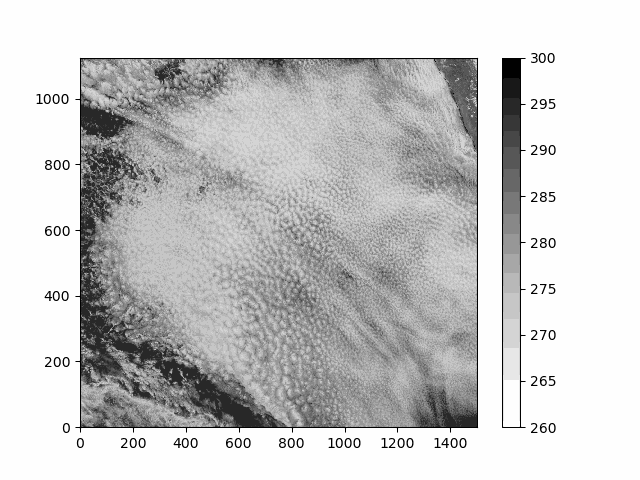

In [16]:
import gif 
from IPython.display import Image
disp = advected.copy()
NT = disp.shape[2]

@gif.frame
def plot_frame(i):
    plt.pcolormesh(disp[:,:,i], cmap='Greys', vmin=260,vmax=300); plt.colorbar();

#Generate frames and save to a gif
frames = [plot_frame(i) for i in range(NT)]
gif.save(frames, 'example.gif', duration=500)
Image(filename='example.gif')

In [23]:
def envelope(Xm, Ym, xcenter, ycenter, length, aspect, angle_deg):
    """
    Creates a 2D elliptical Gaussian blob on a given coordinate grid. Gemini write this. 

    Args:
        Xm (numpy.ndarray): 2D array of x-coordinates (e.g., from np.meshgrid).
        Ym (numpy.ndarray): 2D array of y-coordinates (e.g., from np.meshgrid).
        xcenter (float): x-coordinate of the blob's center.
        ycenter (float): y-coordinate of the blob's center.
        length (float): Standard deviation along the blob's major axis (controls overall size).
                        This is your 'blob_size'.
        aspect (float): Ratio of major to minor axis standard deviation (elongation, >= 1).
                        If < 1, axes are swapped and angle adjusted.
        angle_deg (float): Angle of the major axis in degrees, relative to the x-axis.

    Returns:
        numpy.ndarray: A 2D array representing the elliptical Gaussian blob.
                       Peak amplitude is 1.0 at the center.
    """
    # Ensure aspect ratio is >= 1; if not, swap major/minor axes and adjust angle by 90 degrees
    if aspect < 1.0:
        aspect = 1.0 / aspect
        angle_deg += 90.0

    angle_radians = np.deg2rad(angle_deg)
    sigma_major = length
    sigma_minor = length / aspect

    # Translate coordinates relative to the blob's center
    Xt = Xm - xcenter
    Yt = Ym - ycenter

    # Rotate the translated coordinates to align with the blob's principal axes
    Xr = Xt * np.cos(angle_radians) + Yt * np.sin(angle_radians)
    Yr = -Xt * np.sin(angle_radians) + Yt * np.cos(angle_radians)

    # Calculate the elliptical Gaussian value at each point
    gaussian_blob = np.exp(-(Xr**2 / (2 * sigma_major**2) + Yr**2 / (2 * sigma_minor**2)))

    return gaussian_blob
    
def put_wave(grid, cphase = 14,zamplitude = 100,wavelength = 256*1000.,direction = 215,\
             xcenter=500*1000, ycenter=-500*1000, length=1500*1000.,aspect=3, angle_deg=60):
    
    # Wave properties
    #cphase = 14            # m/s
    #amplitude = 100       # meters, vertical displacement
    #wavelength = 256*1000. # meters
    #direction = 215       # navigation angle of FROM direction in degrees (215 = FROM WSW) 
    # Amplitude modulation by a big smooth Gaussian, elongation only N-S for now 
    #packet_center_x = 1000*1000.  # meters from center of Xm, Ym coordinates  
    #packet_center_y = 0         # pixels from center of Xm, Ym coordinates  
    #packet_width_x  = 800*1000.  # meters! 
    #packet_width_y  = 1000*1000.  # meters! 
    # period = wavelength/cphase 
    
    ## Construct it: 

    k = 2*np.pi/wavelength * np.sin( (direction) *np.pi/180 )   # add 1e-9 in case of 0 denominator
    l = 2*np.pi/wavelength * np.cos( (direction) *np.pi/180 )   # add 1e-9 in case of 0 denominator
    Ampwindow = envelope(Xm, Ym, xcenter, ycenter, length, aspect, angle_deg)  

    for it in range(time_steps):
        t = it*time_resolution     # t is in seconds 
    # dz measures vertical displacements: choose sin(x-ct) phase
        dz = zamplitude*np.sin( k*(Xm - cphase*t)+l*(Ym - cphase*t) ) *Ampwindow

    # wave dx and dy are 90deg behind phase with dz, prop. to wavelength. 
        dxy = (zamplitude/PBLdepth)*wavelength \
              * np.sin( k*(Xm - cphase*t)+l*(Ym - cphase*t) -np.pi/2.) /DX
        dx = dxy * np.sin(direction *np.pi/180.) *Ampwindow 
        dy = dxy * np.cos(direction *np.pi/180.) *Ampwindow

    # Warping by transporting pixels in image, wrapping (periodic) for now. SUBTRACT dy and dx in argument. 
        grid[:,:,it] = ndimage.map_coordinates(grid[:,:,it], \
                                [Y-dy, X-dx], mode='mirror' ) # mirror uses nearby texture
        
    # Modulate (multiply anomalous brightness) by vertical displacement, bright where scrunched 
        #meanval = np.mean(grid[:,:,it])
        #grid[:,:,it] = meanval + (grid[:,:,it]-meanval) * (1 - (dz/PBLdepth)* dB_dlogz)  

    # Modulate (multiply CLOUD brightness) by vertical displacement 
        meanval = np.mean(grid[:,:,it])
        grid[:,:,it] = np.where(grid[:,:,it] < 280, \
                                meanval+( (grid[:,:,it]-meanval) * (1 - (dz/PBLdepth)* dB_dlogz)), \
                                grid[:,:,it])

    return grid 




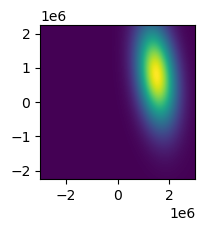

In [24]:
# Playground for envelope specification 

plt.figure(figsize=(2,2))
plt.pcolormesh(Xm, Ym, envelope(Xm, Ym, \
            xcenter=1500*1000, ycenter=800*1000, length=1000*1000.,aspect=2, angle_deg=100)  );

In [25]:
# Put waves into advected image
disp = advected.copy() 

disp = put_wave(disp, cphase = 14,zamplitude = 50,wavelength = 256*1000.,direction = 220,\
             xcenter=-1000*1000, ycenter=-1000*1000, length=500*1000.,aspect=1.5, angle_deg=120)

disp = put_wave(disp, cphase = -10,zamplitude = 50,wavelength = 512*1000.,direction = 180,\
             xcenter=1500*1000, ycenter=800*1000, length=1200*1000.,aspect=2, angle_deg=100)

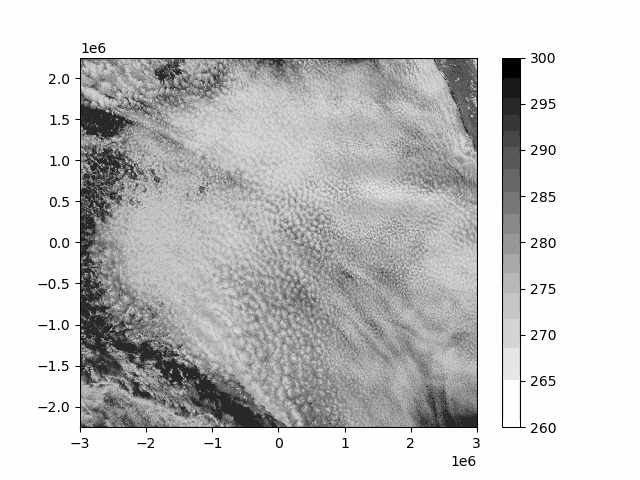

In [26]:
NT = disp.shape[2]

@gif.frame
def plot_frame(i):
    plt.pcolormesh(Xm, Ym, disp[:,:,i], cmap='Greys', vmin=260,vmax=300); plt.colorbar();

#Generate frames and save to a gif
frames = [plot_frame(i) for i in range(NT)]
gif.save(frames, 'example.gif', duration=500)
Image(filename='example.gif')

In [28]:
# Save images as .nc files of the right shape and size for satellite data 
# filename: scene_IR_128km_45deg_amp3_envcenter_realistic 

for it in range(grid.shape[2]):
    ds['CMI'].values = np.flipud(grid[:,:,it])
    filename = 'closedcells_IR_2waves_halfhour'+str(it)+'.nc'
    print(FOLDERNAME+filename)
    ds.to_netcdf(FOLDERNAME+filename)

NameError: name 'grid' is not defined